# Calibration

**This notebook assesses calibration performance of the gradient boosted survival model and recalibrates predictions using isotonic regression.**

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from scipy.stats import linregress
from sklearn.model_selection import StratifiedKFold
from joblib import Parallel, delayed
from sklearn.isotonic import IsotonicRegression
from sksurv.metrics import brier_score

from utils.calibration import calculate_calibration_curve, calibrate_survival_predictions

## Import Data

In [2]:
survival_predictions_df = pd.read_csv('../outputs/gb_survival_predictions.csv')

In [3]:
survival_predictions_df = survival_predictions_df[['PatientID', 'risk_score', 'psurv_180', 'psurv_365']]

In [4]:
survival_predictions_df.shape

(9030, 4)

In [5]:
dtype_map = pd.read_csv('../outputs/ioio_tki_features_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
ioio_tki_df = pd.read_csv('../outputs/ioio_tki_features_df.csv', dtype = dtype_map)

In [6]:
ioio_tki_df.shape

(1339, 174)

In [7]:
df = pd.merge(ioio_tki_df, survival_predictions_df, on = 'PatientID', how = 'left')

In [8]:
df.shape

(1339, 177)

In [9]:
df = df.query('adv_diagnosis_year <= 2021')

In [10]:
df.shape

(1135, 177)

## Raw Calibration Assessment

In [11]:
cal_df = calculate_calibration_curve(df, 'psurv_180', 180)

In [12]:
cal_df

,bin,predicted,observed,n,obs_lo,obs_hi
0,"(-0.00099882, 0.404]",0.221382,0.373893,114,0.278353,0.460787
1,"(0.404, 0.6]",0.511620,0.550493,113,0.451073,0.639165
2,"(0.6, 0.683]",0.641081,0.652327,114,0.550684,0.729711
3,"(0.683, 0.745]",0.716076,0.700603,113,0.604584,0.776420
4,"(0.745, 0.792]",0.768498,0.746069,114,0.648137,0.812560
5,"(0.792, 0.831]",0.812747,0.881027,113,0.784255,0.916496
6,"(0.831, 0.862]",0.847252,0.864234,113,0.776751,0.910250
7,"(0.862, 0.884]",0.871897,0.909210,114,0.836824,0.949498
8,"(0.884, 0.905]",0.893162,0.936498,113,0.859667,0.962712
9,"(0.905, 0.943]",0.920521,0.963546,114,0.905532,0.986049


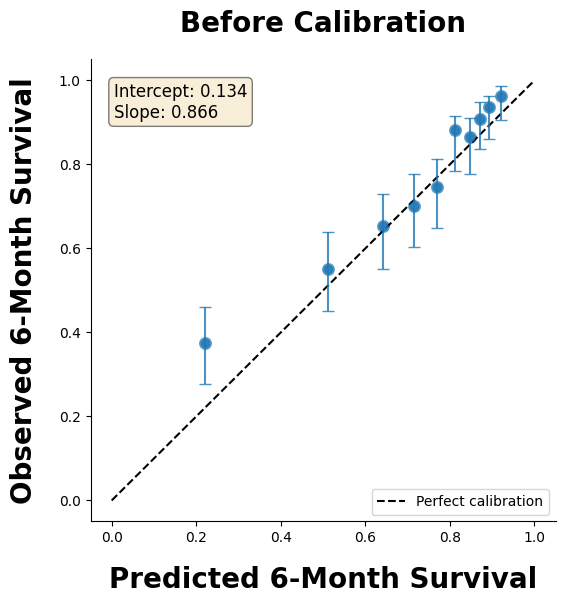

In [13]:
slope_orig, intercept_orig, _, _, _ = linregress(
    cal_df['predicted'], 
    cal_df['observed']
)

# Plot
plt.figure(figsize = (6, 6))
plt.scatter(cal_df['predicted'], cal_df['observed'], s = 70, alpha = 0.6)
plt.plot([0, 1], [0, 1], 'k--', label = 'Perfect calibration')

# Error bar 
yerr = np.vstack([
    cal_df['observed'] - cal_df['obs_lo'],
    cal_df['obs_hi'] - cal_df['observed']
])

plt.errorbar(
    cal_df['predicted'],
    cal_df['observed'],
    yerr = yerr,
    fmt = 'o',           
    elinewidth = 1.5,    
    capsize = 4,         
    alpha = 0.8
)

# Add text box with calibration metrics
textstr = f'Intercept: {intercept_orig:.3f}\nSlope: {slope_orig:.3f}'
plt.text(0.05, 0.95, textstr, transform = plt.gca().transAxes, 
         fontsize = 12, verticalalignment = 'top',
         bbox = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5))

plt.xlabel('Predicted 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.ylabel('Observed 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.title('Before Calibration',  weight = 'bold', size = 20, pad = 20)
plt.legend()

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig('../outputs/uncalibrated_gb_6m_survival_prediction_plot.pdf', format = 'pdf', bbox_inches = 'tight')

plt.show()

## Isotonic Calibration Using Cross Validation 

In [14]:
# Prepare structured array for survival outcomes
y_dtype = [('event', bool), ('duration', float)]

y = np.array([tuple(x) for x in df[['event', 'duration']].values],
             dtype = y_dtype)

In [15]:
df, brier_scores = calibrate_survival_predictions(df, y, 'psurv_180', 180)


=== Fold 1/5 ===
Brier score at 180 days (calibrated): 0.1749

=== Fold 2/5 ===
Brier score at 180 days (calibrated): 0.1635

=== Fold 3/5 ===
Brier score at 180 days (calibrated): 0.1517

=== Fold 4/5 ===
Brier score at 180 days (calibrated): 0.1367

=== Fold 5/5 ===
Brier score at 180 days (calibrated): 0.1376

=== Summary ===
psurv_180_calibrated computed: 1135

=== Brier Scores at 180 days (calibrated) ===
Mean: 0.1529 ± 0.0148


In [16]:
df_final_calibrated = df[['PatientID', 'psurv_180_calibrated']]

In [17]:
df_final_calibrated.to_csv('../outputs/gb_6m_survival_predictions_calibrated.csv', index = False)

In [18]:
cal_iso_df = calculate_calibration_curve(df, 'psurv_180_calibrated', 180)

In [19]:
cal_iso_df

,bin,predicted,observed,n,obs_lo,obs_hi
0,"(-0.001, 0.433]",0.370998,0.407651,120,0.311682,0.493501
1,"(0.433, 0.67]",0.573308,0.579712,142,0.491727,0.657844
2,"(0.67, 0.684]",0.681783,0.686968,80,0.569980,0.778196
3,"(0.684, 0.726]",0.706209,0.700385,112,0.602823,0.774684
4,"(0.726, 0.8]",0.755115,0.765789,128,0.673731,0.825342
5,"(0.8, 0.872]",0.856618,0.819741,121,0.731132,0.874340
6,"(0.872, 0.92]",0.897540,0.879895,103,0.787996,0.923398
7,"(0.92, 0.927]",0.922350,0.942013,106,0.870874,0.971151
8,"(0.927, 0.954]",0.947920,0.937359,131,0.876860,0.967174
9,"(0.954, 1.0]",0.973256,0.921019,92,0.840655,0.961144


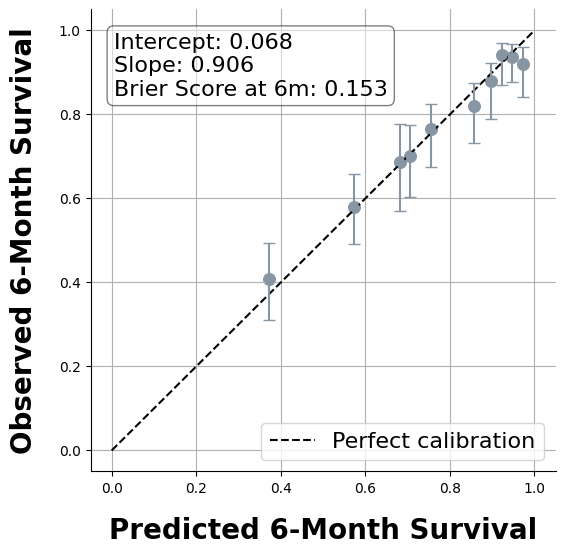

In [20]:
slope_iso, intercept_iso, _, _, _ = linregress(
    cal_iso_df['predicted'], 
    cal_iso_df['observed']
)

# Plot
plt.figure(figsize = (6, 6))
plt.scatter(cal_iso_df['predicted'], cal_iso_df['observed'], s = 70, color = '#8896A4')
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')

# Error bar 
yerr = np.vstack([
    cal_iso_df['observed'] - cal_iso_df['obs_lo'],
    cal_iso_df['obs_hi'] - cal_iso_df['observed']
])

plt.errorbar(
    cal_iso_df['predicted'],
    cal_iso_df['observed'],
    yerr = yerr,
    fmt = 'o',           
    elinewidth = 1.5,
    color = '#8896A4',
    capsize = 4
)

# Add text box with calibration metrics
textstr = f'Intercept: {intercept_iso:.3f}\nSlope: {slope_iso:.3f}\nBrier Score at 6m: {np.mean(brier_scores):.3f}'
plt.text(0.05, 0.95, textstr, transform = plt.gca().transAxes, 
         fontsize = 16, verticalalignment = 'top',
         bbox = dict(boxstyle = 'round', facecolor = 'white', alpha = 0.5))

plt.xlabel('Predicted 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.ylabel('Observed 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
#plt.title('After Isotonic Calibration',  weight = 'bold', size = 20, pad = 20)
plt.legend(fontsize=16)
plt.grid(True)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig('../outputs/calibrated_gb_6m_survival_prediction_plot.pdf', format = 'pdf', bbox_inches = 'tight')

plt.show()